### Import Libraries

In [20]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt 


### Import File from Computer

In [21]:
#Path.cwd() gets the current directory I am in
base_dir = Path.cwd()

# .parent moves up the project folder to one level up
# /"filepath2"/"fileloc2"/"filename2" mmoves the location to the target folder

file_path = base_dir.parent/"Assignment1"/"Moist.xlsx"


# It is good practice to resolve the path to ensure its absolute and clean
file_path = file_path.resolve()

print(f"Loading dataset from {file_path}")

print (file_path.exists())

if file_path.exists():
    df_sensors = pd.read_excel(file_path)
    print("dataset loaded")
else:
    print("Path not found")


Loading dataset from /mnt/Codebase/Learning/MachineLearning/Assignment1/Moist.xlsx
True
dataset loaded


## Access Data

In [22]:
from sklearn import datasets
dir(datasets)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_arff_parser',
 '_base',
 '_california_housing',
 '_covtype',
 '_kddcup99',
 '_lfw',
 '_olivetti_faces',
 '_openml',
 '_rcv1',
 '_samples_generator',
 '_species_distributions',
 '_svmlight_format_fast',
 '_svmlight_format_io',
 '_twenty_newsgroups',
 'clear_data_home',
 'dump_svmlight_file',
 'fetch_20newsgroups',
 'fetch_20newsgroups_vectorized',
 'fetch_california_housing',
 'fetch_covtype',
 'fetch_file',
 'fetch_kddcup99',
 'fetch_lfw_pairs',
 'fetch_lfw_people',
 'fetch_olivetti_faces',
 'fetch_openml',
 'fetch_rcv1',
 'fetch_species_distributions',
 'get_data_home',
 'load_breast_cancer',
 'load_diabetes',
 'load_digits',
 'load_files',
 'load_iris',
 'load_linnerud',
 'load_sample_image',
 'load_sample_images',
 'load_svmlight_file',
 'load_svmlight_files',
 'load_wine',
 'make_biclusters',
 'make_blobs',
 'make_checkerboard

## Dataset Analysis

In [23]:
df_sensors.columns

Index(['Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 5', 'Sensor 6',
       'Moisture content'],
      dtype='str')

In [24]:
df_sensors.head()

,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Moisture content
0,0.108138,19.838454,1.765294,1.873501,0.028025,0.031987,37.76
1,0.156370,7.994571,2.208907,2.365429,0.067242,0.075948,38.47
2,0.094363,3.583663,1.797682,1.892188,0.092256,0.103186,40.96
3,0.119700,14.946371,2.341789,2.461699,0.068006,0.074083,38.86
4,0.131335,9.165366,2.184133,2.316201,0.063899,0.071026,42.61


In [25]:
df_sensors.info()

<class 'pandas.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sensor 1          957 non-null    float64
 1   Sensor 2          957 non-null    float64
 2   Sensor 3          957 non-null    float64
 3   Sensor 4          957 non-null    float64
 4   Sensor 5          957 non-null    float64
 5   Sensor 6          957 non-null    float64
 6   Moisture content  957 non-null    float64
dtypes: float64(7)
memory usage: 52.5 KB


In [26]:
df_sensors.describe()

,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Moisture content
count,957.000000,957.000000,957.000000,957.000000,957.000000,957.000000,957.000000
mean,0.085949,3.164592,2.017973,2.106660,0.168714,0.182427,43.262344
std,0.014766,2.569510,0.138426,0.147460,0.065325,0.069081,7.465865
min,0.056471,0.388231,1.581123,1.732602,0.020912,0.026362,24.590000
25%,0.074074,1.118528,1.928467,2.010880,0.116027,0.126545,38.380000
50%,0.084506,2.214262,2.027380,2.116448,0.162281,0.176100,42.020000
75%,0.096626,4.882693,2.097948,2.192738,0.213827,0.230800,47.739426
max,0.162489,19.838454,2.562184,2.687183,0.411207,0.434284,61.217587


### Working with Missing Value

In [27]:
#Check if there is any missing value
df_sensors.isnull().values.any()

np.False_

In [28]:
# Check if columns have the missing value
df_sensors.isnull().sum()

Sensor 1            0
Sensor 2            0
Sensor 3            0
Sensor 4            0
Sensor 5            0
Sensor 6            0
Moisture content    0
dtype: int64

In [29]:
#Check the rows with missing values
df_sensors[df_sensors.isnull().any(axis=1)]

,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Moisture content


In [30]:
# Removing the rows with missing values
df_sensors = df_sensors.dropna()

In [31]:
#check if there is missing values anymore
df_sensors.isnull().values.any()

np.False_

### Data Slicing and Labeling

In [32]:
df_sensors.describe()

,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Moisture content
count,957.000000,957.000000,957.000000,957.000000,957.000000,957.000000,957.000000
mean,0.085949,3.164592,2.017973,2.106660,0.168714,0.182427,43.262344
std,0.014766,2.569510,0.138426,0.147460,0.065325,0.069081,7.465865
min,0.056471,0.388231,1.581123,1.732602,0.020912,0.026362,24.590000
25%,0.074074,1.118528,1.928467,2.010880,0.116027,0.126545,38.380000
50%,0.084506,2.214262,2.027380,2.116448,0.162281,0.176100,42.020000
75%,0.096626,4.882693,2.097948,2.192738,0.213827,0.230800,47.739426
max,0.162489,19.838454,2.562184,2.687183,0.411207,0.434284,61.217587


In [33]:
df_sensors.iloc[0:3,1:5] # Integer based indexing-positional indexing


,Sensor 2,Sensor 3,Sensor 4,Sensor 5
0,19.838454,1.765294,1.873501,0.028025
1,7.994571,2.208907,2.365429,0.067242
2,3.583663,1.797682,1.892188,0.092256


In [35]:
df_sensors.loc[9:25,'Sensor 2':'Moisture content'] #label based indexing

,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Moisture content
9,19.647044,1.581123,1.732602,0.020912,0.026362,59.78
10,3.152728,2.316685,2.479827,0.105832,0.118944,58.72
11,1.821919,2.562184,2.687183,0.184569,0.199338,58.32
12,1.285951,2.426994,2.513149,0.233515,0.247613,57.81
13,6.522291,2.532982,2.639719,0.137143,0.146690,43.90
14,4.083910,2.014165,2.104573,0.114762,0.124992,44.06
15,2.159202,2.215385,2.320840,0.156725,0.170324,43.13
16,0.826661,2.011434,2.099988,0.221481,0.240873,44.57
17,3.997853,2.059673,2.146749,0.113469,0.122794,41.36
18,10.246767,2.232122,2.371271,0.068613,0.076361,43.61


### Data Labeling

In [ ]:
# This code uses Data Labeling using lambda function and makes best use of lambda functions first to define values based on expression and then by 
# using "apply" method to utilize the lambda function to add labels to the dataset (or to do row/column based operations)

label_mapping = {
    (lambda x:x <=35): 0,
    (lambda x:x > 35 and x <=40): 1,
    (lambda x:x >40):2
}

# Apply label mapping to create a new label column
def get_label(moisture):
    for condition, label in label_mapping.items():
        if condition(moisture):
            return label

df_sensors['Label'] = df_sensors['Moisture content'].apply(get_label)

In [38]:
df_sensors.head()

,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Moisture content,Label
0,0.108138,19.838454,1.765294,1.873501,0.028025,0.031987,37.76,1
1,0.156370,7.994571,2.208907,2.365429,0.067242,0.075948,38.47,1
2,0.094363,3.583663,1.797682,1.892188,0.092256,0.103186,40.96,2
3,0.119700,14.946371,2.341789,2.461699,0.068006,0.074083,38.86,1
4,0.131335,9.165366,2.184133,2.316201,0.063899,0.071026,42.61,2


# Use Linear Regression 

### Import Additional Libraries

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

### Check correlation between features

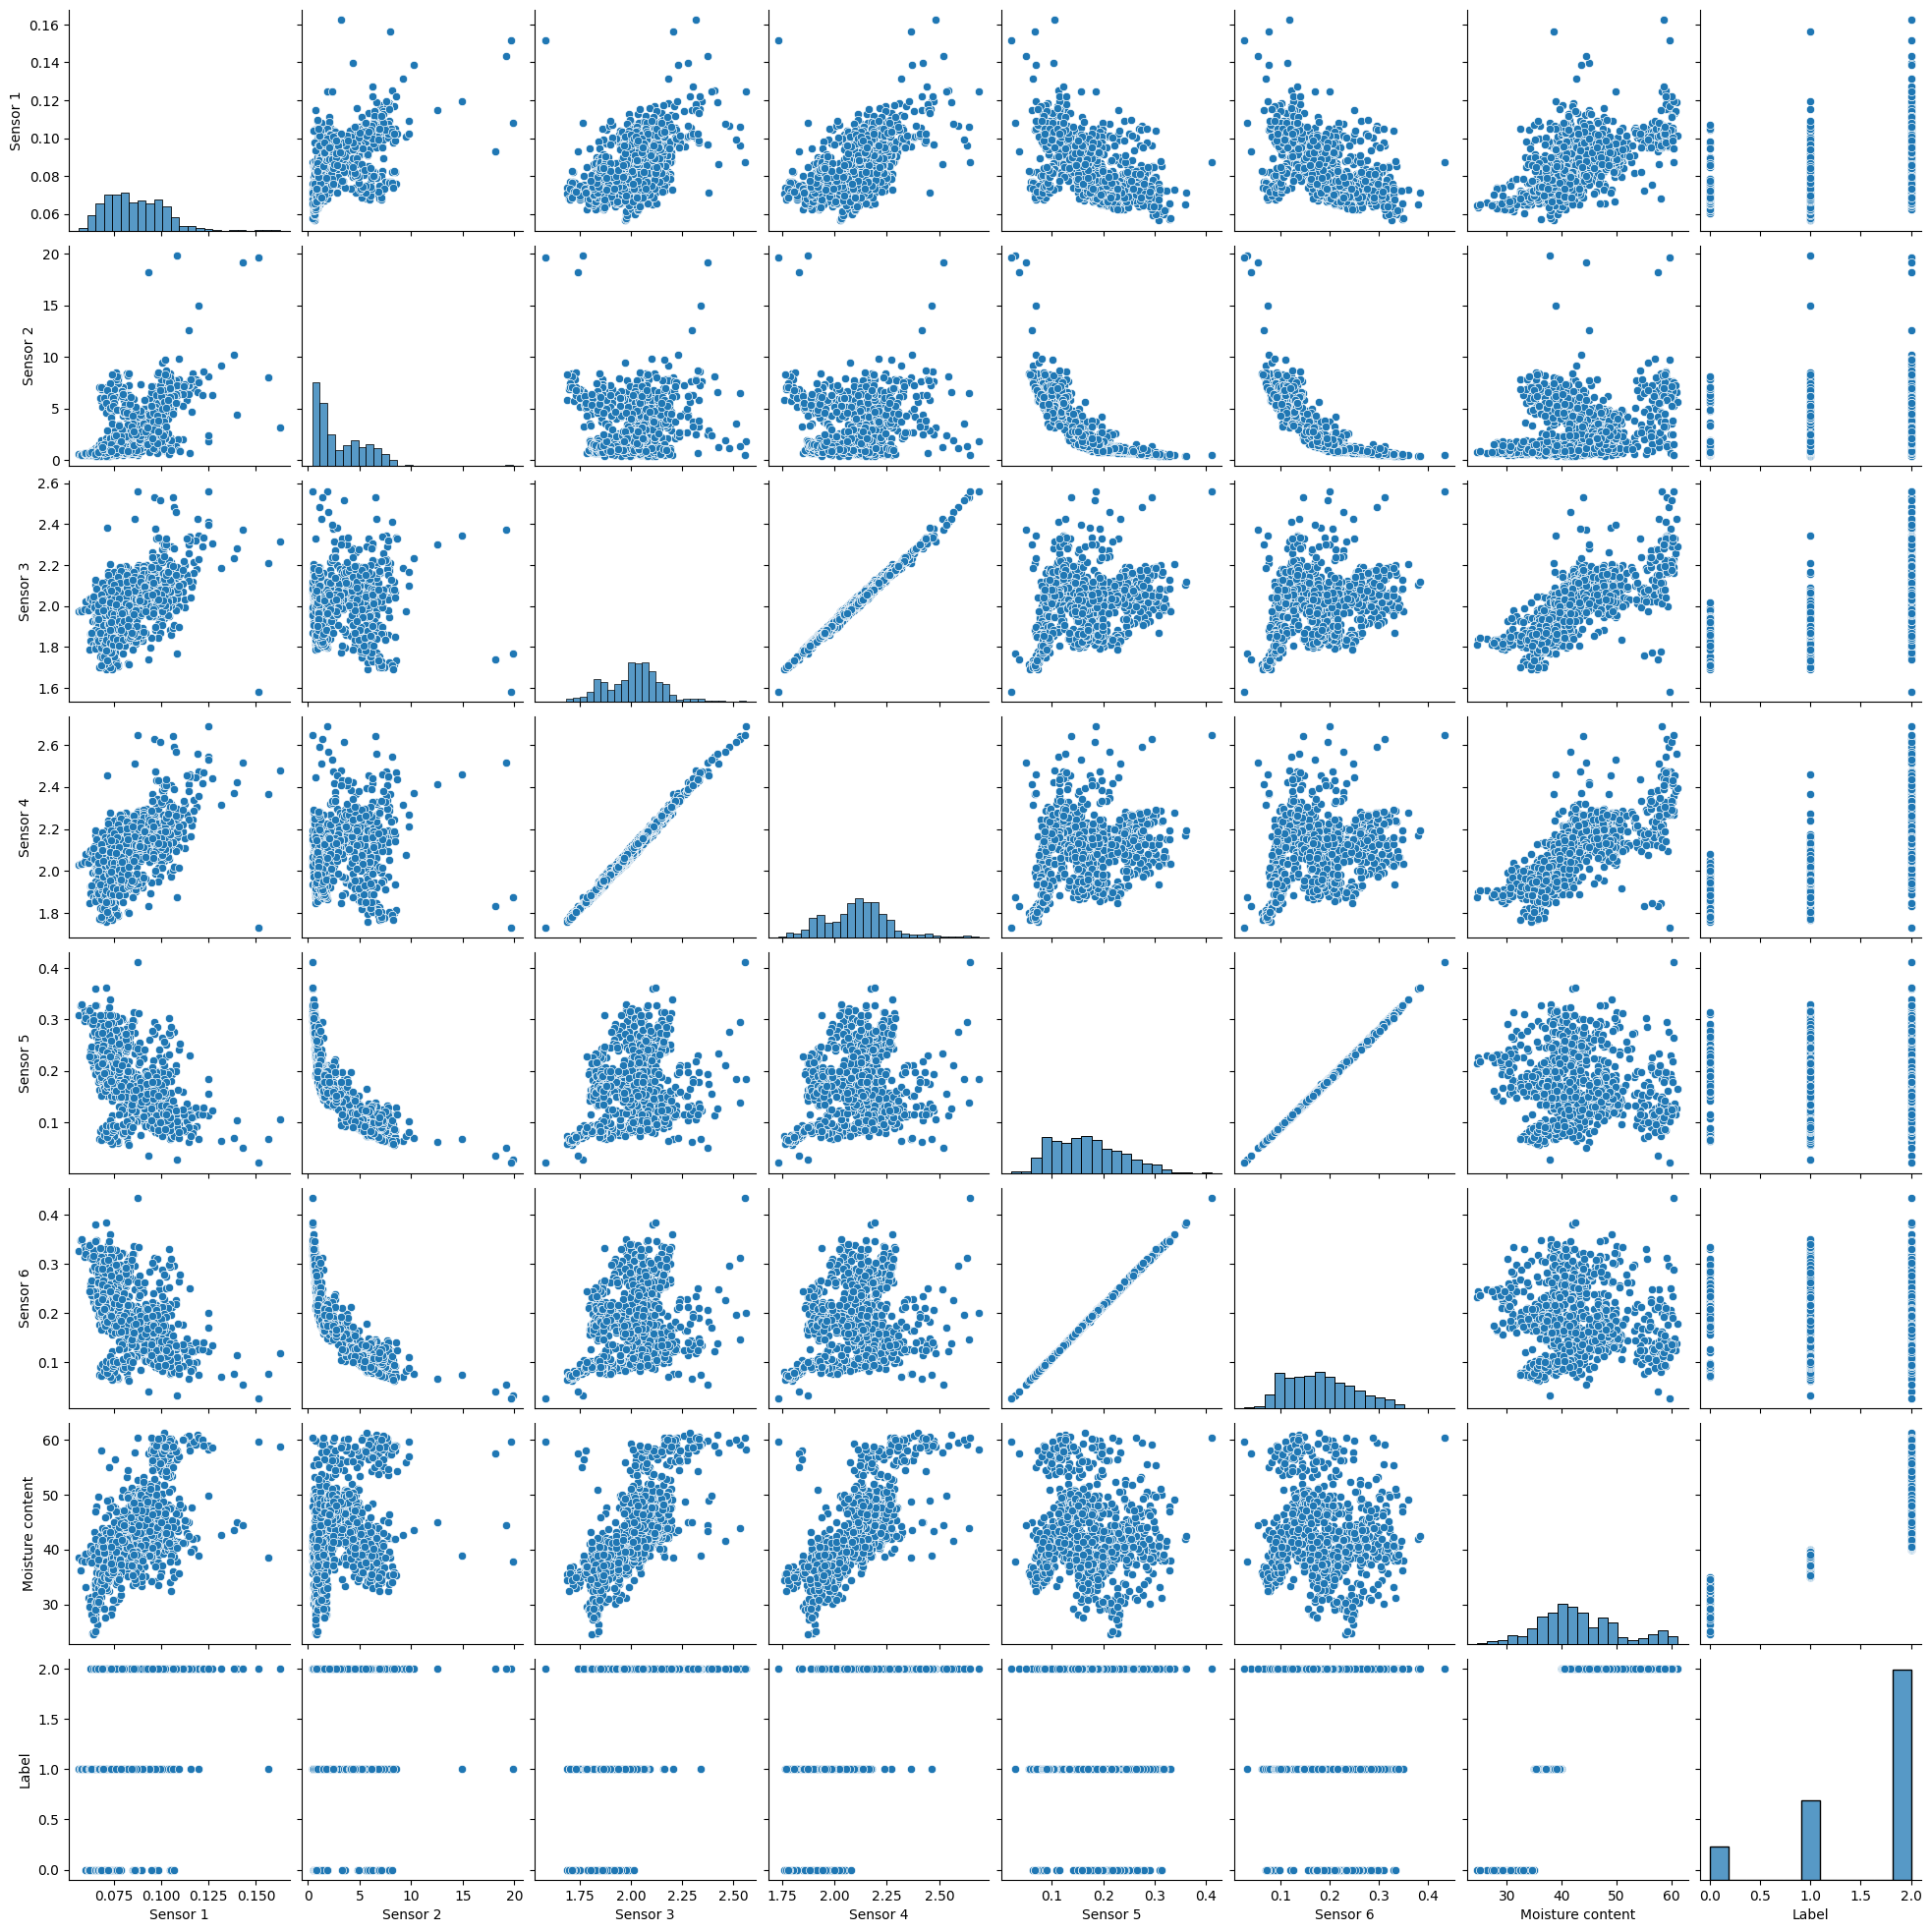

In [40]:
sns.pairplot(df_sensors)
plt.show()

### Select Features and Target

In [48]:
x = df_sensors.drop(columns="Moisture content") 
x = df_sensors.drop(columns="Label")
y = df_sensors["Moisture content"]

## Train Test Split

In [51]:
# TRaining dataset 80% Test dataset 20%

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

### Model selection and Training

In [52]:
model = LinearRegression()
model.fit(X_train, y_train)

# Model Prediction

y_pred = model.predict(X_test)

## Model Evaluation

In [54]:
# MSE 
mse = mean_squared_error(y_test, y_pred)
print ("MSE:", mse)

# RMSE
rmse = np.sqrt(mse)
print("RMSE:", rmse)

#R2-score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)



MSE: 5.015840589030267e-29
RMSE: 7.08225994229968e-15
R2 Score: 1.0


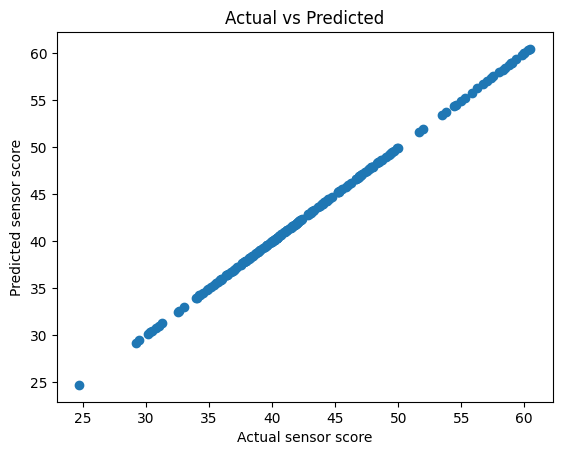

In [55]:
# Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual sensor score")
plt.ylabel("Predicted sensor score")
plt.title("Actual vs Predicted")
plt.show()

## Model Coefficients

In [56]:
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient":model.coef_
})

print (coefficients)

intercept = model.intercept_
print (intercept)

            Feature   Coefficient
0          Sensor 1 -1.855440e-13
1          Sensor 2  5.551115e-16
2          Sensor 3 -2.396451e-13
3          Sensor 4  2.230351e-13
4          Sensor 5  1.196846e-12
5          Sensor 6 -1.128712e-12
6  Moisture content  1.000000e+00
7.105427357601002e-15


## SNS Regression Plot

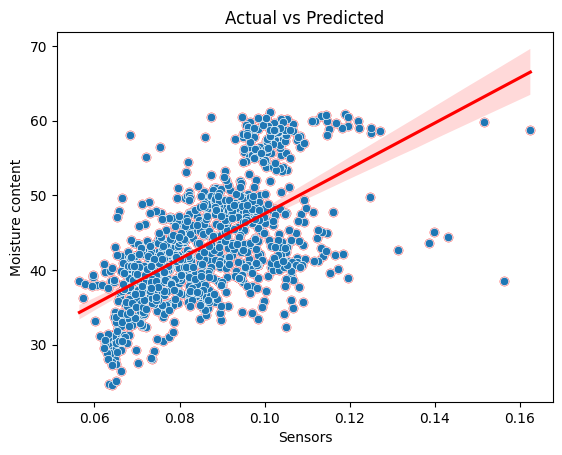

In [ ]:
sns.regplot(data=df_sensors, x="Sensor 1", y="Moisture content", color="red")
sns.scatterplot(data=df_sensors, x="Sensor 1", y="Moisture content")
plt.xlabel("Sensors")
plt.ylabel("Moisture content")
plt.title("Corelation between sensor 1 data and moisture content")
plt.show()


## Apply Regularizations

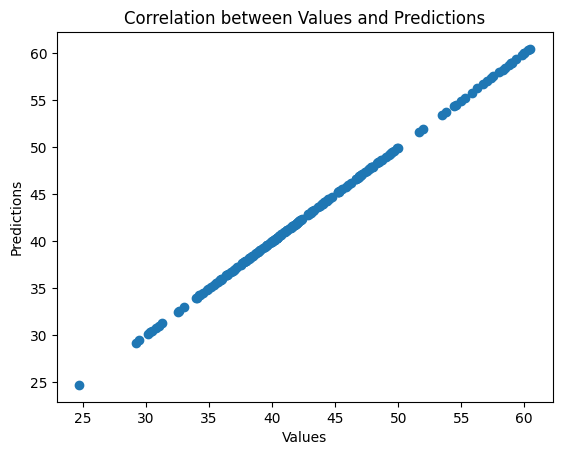

MSE	: 4.9838610555069996e-08
R2 Score: 0.9999999990801327


In [60]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge()

ridge.fit(X_train, y_train)
y_pred_Rd = ridge.predict(X_test)
plt.scatter(y_test, y_pred_Rd )
plt.xlabel("Values")
plt.ylabel("Predictions")
plt.title("Correlation between Values and Predictions")
plt.show()
print(f"MSE\t: {mean_squared_error(y_test, y_pred_Rd )}")
print(f"R2 Score: {r2_score(y_test, y_pred_Rd )}")

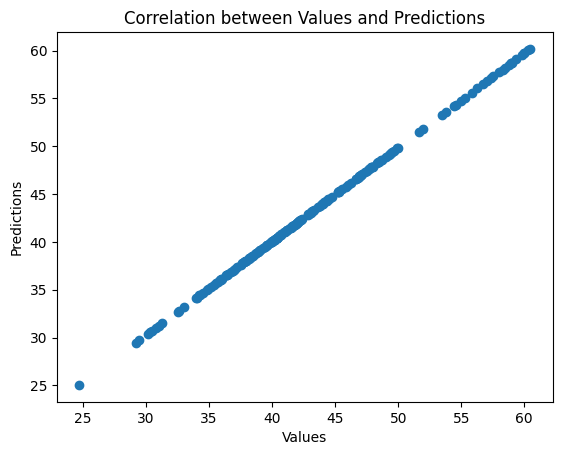

MSE	: 0.017246836302578842
R2 Score: 0.9996816764927339


In [61]:
lasso = Lasso()

lasso.fit(X_train, y_train)
y_pred_LS = lasso.predict(X_test)
plt.scatter(y_test, y_pred_LS )
plt.xlabel("Values")
plt.ylabel("Predictions")
plt.title("Correlation between Values and Predictions")
plt.show()
print(f"MSE\t: {mean_squared_error(y_test, y_pred_LS )}")
print(f"R2 Score: {r2_score(y_test, y_pred_LS )}")

### Check if the model overfits

In [62]:
print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))

Train score: 1.0
Test score: 1.0
